In [1]:
import pandas as pd
import numpy as np

np.random.seed(42)

n = 2000

data = pd.DataFrame({
    "Age": np.random.randint(18, 80, n),
    "Gender": np.random.choice(["Male", "Female"], n),
    "BMI": np.round(np.random.uniform(18, 40, n), 1),
    "BloodPressure": np.random.randint(90, 180, n),
    "Cholesterol": np.random.randint(120, 300, n),
    "Glucose": np.random.randint(70, 220, n),
    "Smoking": np.random.choice(["Yes", "No"], n),
    "PhysicalActivity": np.random.choice(["Low", "Medium", "High"], n),
    "FamilyHistory": np.random.choice(["Yes", "No"], n),
    "HeartRate": np.random.randint(55, 120, n)
})

# Create target based on risk-related features
risk_score = (
    (data["Age"] > 50).astype(int) +
    (data["BMI"] > 30).astype(int) +
    (data["BloodPressure"] > 140).astype(int) +
    (data["Cholesterol"] > 220).astype(int) +
    (data["Glucose"] > 140).astype(int) +
    (data["Smoking"] == "Yes").astype(int) +
    (data["FamilyHistory"] == "Yes").astype(int)
)

data["Disease_Risk"] = (risk_score >= 3).astype(int)

data.head()

,Age,Gender,BMI,BloodPressure,Cholesterol,Glucose,Smoking,PhysicalActivity,FamilyHistory,HeartRate,Disease_Risk
0,56,Male,39.3,96,164,111,No,Medium,No,78,0
1,69,Male,22.0,157,177,137,Yes,Medium,Yes,64,1
2,46,Male,18.5,108,298,139,Yes,Medium,Yes,67,1
3,32,Female,33.8,120,245,147,Yes,Medium,No,98,1
4,60,Female,27.2,124,281,159,No,Medium,Yes,93,1


In [2]:
print("Dataset Shape:", data.shape)

Dataset Shape: (2000, 11)


In [3]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Age               2000 non-null   int32  
 1   Gender            2000 non-null   object 
 2   BMI               2000 non-null   float64
 3   BloodPressure     2000 non-null   int32  
 4   Cholesterol       2000 non-null   int32  
 5   Glucose           2000 non-null   int32  
 6   Smoking           2000 non-null   object 
 7   PhysicalActivity  2000 non-null   object 
 8   FamilyHistory     2000 non-null   object 
 9   HeartRate         2000 non-null   int32  
 10  Disease_Risk      2000 non-null   int64  
dtypes: float64(1), int32(5), int64(1), object(4)
memory usage: 132.9+ KB


In [4]:
data.describe()

,Age,BMI,BloodPressure,Cholesterol,Glucose,HeartRate,Disease_Risk
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,49.114000,29.112450,135.213000,208.831500,143.750000,86.877500,0.732000
std,17.926564,6.332941,26.027185,51.105508,42.753005,18.987753,0.443028
min,18.000000,18.000000,90.000000,120.000000,70.000000,55.000000,0.000000
25%,34.000000,23.600000,112.000000,164.000000,107.000000,70.000000,0.000000
50%,49.000000,29.300000,135.000000,209.000000,143.000000,87.000000,1.000000
75%,65.000000,34.625000,158.000000,252.000000,181.000000,104.000000,1.000000
max,79.000000,40.000000,179.000000,299.000000,219.000000,119.000000,1.000000


In [5]:
print(data["Disease_Risk"].value_counts())

Disease_Risk
1    1464
0     536
Name: count, dtype: int64


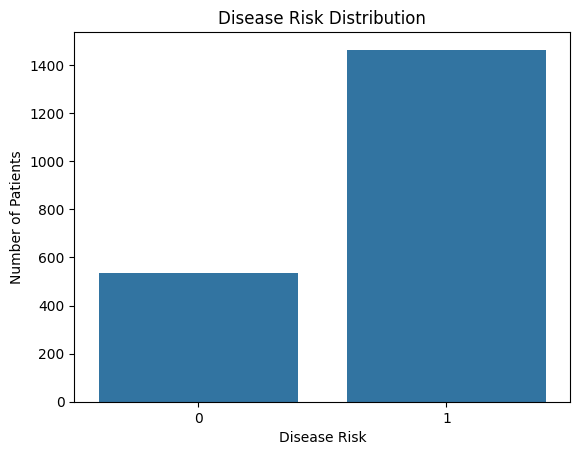

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.countplot(x="Disease_Risk", data=data)

plt.title("Disease Risk Distribution")
plt.xlabel("Disease Risk")
plt.ylabel("Number of Patients")
plt.show()